In [1]:
#@markdown Let's check if we are using the GPU. If not, go to **Runtime** $\rightarrow$ **Change runtime type** $\rightarrow$ **T4 GPU**
import sys
if 'google.colab' in sys.modules:
    from IPython import get_ipython
    get_ipython().system('nvidia-smi')

In [2]:
#@markdown Install required libraries
import sys
if 'google.colab' in sys.modules:
    from IPython import get_ipython
    get_ipython().system('pip install -qq -U diffusers==0.32.2 transformers==4.49.0 accelerate==1.5.1 scipy==1.15.2 safetensors==0.5.3')

In [1]:
#@markdown Download the model
import requests
from PIL import Image
from io import BytesIO
from diffusers import StableDiffusionUpscalePipeline
import torch

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
dtype = torch.float16 if device == "cuda" else torch.float32

# load model and scheduler
model_id = "stabilityai/stable-diffusion-x4-upscaler"
pipeline = StableDiffusionUpscalePipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
    variant="fp16" if device == "cuda" else None,
)
pipeline = pipeline.to(device)

/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/fbi005/miniconda3/envs/diffusion/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warnin

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /Users/fbi005/.cache/huggingface/hub/models--stabilityai--stable-diffusion-x4-upscaler/snapshots/572c99286543a273bfd17fac263db5a77be12c4c/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text(0.5, 1.0, 'Low res img')

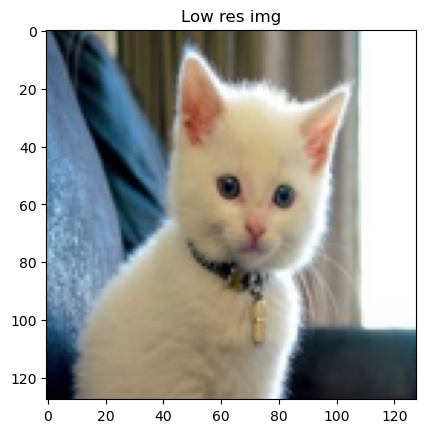

In [2]:
#@markdown Provide image to upscale
import matplotlib.pyplot as plt
url = "https://huggingface.co/datasets/hf-internal-testing/diffusers-images/resolve/main/sd2-upscale/low_res_cat.png" #@param {type:'string'}
response = requests.get(url)
low_res_img = Image.open(BytesIO(response.content)).convert("RGB")
low_res_img = low_res_img.resize((128, 128))

plt.imshow(low_res_img)
plt.title("Low res img")

  0%|          | 0/75 [00:00<?, ?it/s]

/Users/fbi005/miniconda3/envs/diffusion/lib/python3.11/site-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion_upscale.py:528: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


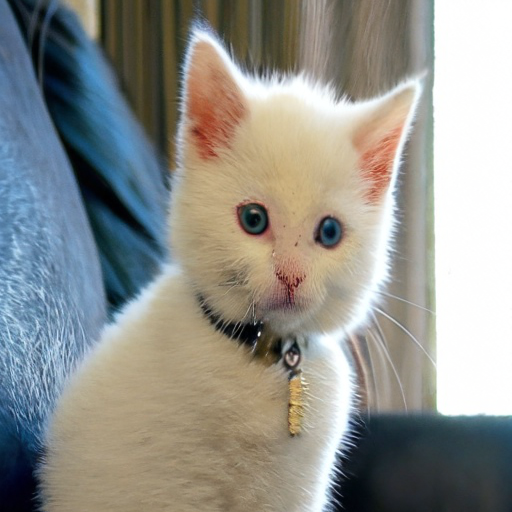

In [3]:
#@markdown Upscale image
prompt = "a white cat" #@param {type:'string'}
upscaled_image = pipeline(prompt=prompt, image=low_res_img).images[0]
upscaled_image